# Structural Estimation and Reinforcement Learning for Optimal Music Release Timing
**Author:** Brad Beecher  
**Student No.** 94332947
**Course:** ECON 622 
**Date:** April 2026

---

## Project Overview
This project develops a structural econometric framework to solve the "Release Timing Problem" in the music industry. I model the streaming lifecycle of a track as a function of latent artist potential, market-wide "heat" cycles, and genre-specific trends. The goal is to determine the optimal entry point into the market to maximize a track's discounted lifetime revenue.

## Structural Model Specification
The estimation follows a two-stage process to map observed streaming data to a dynamic decision environment.

### Stage I: Streaming Estimation (`structural_estimation.py`)
I model the daily log-streams ($y_{i,t}$) of track $i$ at age $t$ using a structural potential-decay form:
$$\ln(y_{i,t} + \epsilon) = \eta_i + \beta_m X_{\tau} + \beta_g X_{g,\tau} - \lambda \cdot t + u_{i,t}$$

* **$\eta_i$ (Artist Fixed Effects):** Captures the baseline "power" of the dominant artist.
* **$X_{\tau}, X_{g,\tau}$ (Market/Genre Heat):** Normalized conditions at the time of release ($\tau$) representing market-wide and genre-specific shocks.
* **$\lambda$ (Decay Rate):** Estimates the structural "half-life" of a track’s popularity as it ages.
* **Implementation:** Estimated using **JAX** with an `optax` multi-learning rate optimizer to simultaneously handle high-dimensional fixed effects and structural parameters.

### Stage II: State Transition Dynamics (`estimate_state_process.py`)
To enable forward-looking behavior, I characterize the evolution of the market states ($s_t = [\ln X_t, \ln X_{g,t}]'$) using a **Vector Autoregression (VAR(1))**:
$$s_{t+1} = \Phi s_t + \xi_{t+1}, \quad \xi \sim N(0, \Sigma)$$
The transition matrix $\Phi$ and shock covariance $\Sigma$ are estimated via OLS to ensure the system is stationary ($|\text{eig}(\Phi)| < 1$), allowing for a stable infinite-horizon solution.

## 3. Policy Optimization (`dqn_trainer.py`)
With the structural parameters ($\beta, \lambda, \eta$) and transition dynamics ($\Phi, \Sigma$) identified, I map the econometrics into a **Deep Q-Network (DQN)** environment (`market_env.py`). 

* **State Space:** Current Market and Genre Heat.
* **Action Space:** {Wait, Release}.
* **Reward:** The discounted lifetime streams ($L_i$) realized upon release, calculated using the estimated structural parameters:
$$R = (\eta + \beta_m e^{s_m} + \beta_g e^{s_g}) \cdot \sum_{t=0}^{365} \delta^t (t e^{-\lambda t})$$

The resulting policy $\pi(s)$ provides a mapping from market conditions to the optimal release decision, providing a quantitative tool for strategic timing in the streaming era.

In [1]:
# Uncomment this to install the environment packages
#%pip install python-dotenv kaggle spotipy pandas matplotlib numpy statsmodels scipy scikit-learn jax optax torch seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import torch
import random
import os

def set_seed(seed=42):

    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    np.random.seed(seed)
    
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    

    os.environ['TF_CUDNN_DETERMINISTIC'] = '1' 

set_seed(42)


from download_kaggle_data import download_kaggle_data
from build_estimation_dataset import build_estimation_dataset
from estimate_state_process import estimate_state_process
from structural_estimation import prepare_jax_data
from structural_estimation import train_model
from structural_estimation import summarize_params

from market_env import MarketEnv
from dqn_agent import DQNAgent
from dqn_trainer import DQNTrainer
from dqn_evaluation import plot_policy_map
from dqn_evaluation import run_diagnostics

## Data Acquisition and Pipeline Engineering

The empirical foundation of this project is built upon a two-stage data pipeline: automated acquisition and a rigorous feature engineering workflow.

### Automated Data Acquisition (`download_kaggle_data.py`)
To ensure reproducibility and handle large-scale datasets, the project utilizes the **Kaggle API**. 
* **Authentication:** Credentials are managed via a `.env` file for security. An API key can be obtained from Kaggle.com or the provided datasets.
* **Process:** The script automatically pulls the specified music industry datasets (Spotify Charts and Track Metadata) and extracts them into a local `/data` directory.


In [2]:
#Data Integration: Merge the Kaggle charts.csv with Spotify API metadata.

download_kaggle_data("maharshipandya/-spotify-tracks-dataset")
download_kaggle_data("jfreyberg/spotify-chart-data")



Authenticated with Kaggle.
Dataset URL: https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset
Download complete! You can now access the CSVs in the /data folder.
Authenticated with Kaggle.
Dataset URL: https://www.kaggle.com/datasets/jfreyberg/spotify-chart-data
Download complete! You can now access the CSVs in the /data folder.



### Estimation Dataset Construction (`build_estimation_dataset.py`)
Converting raw transaction-level chart data into a structural estimation dataset requires several high-dimensional transformations:

#### A. Track Age and Temporal Alignment
Because I was unable to obtain release dates from Spotify (after being locked out by their API), I compute an **approximate release date** by finding the first appearance of a `track_id` in the dataset. `age_days` is then calculated as the delta between the chart date and this proxy release date.

#### B. Artist Power and Fixed Effects Grouping
To manage the high dimensionality of the artist state space, I implement an **"Artist Power"** metric:
1. **Cleaning:** Parsing nested JSON-like strings in the artist column into usable lists.
2. **Scoring:** Computing the mean stream count across all appearances for every artist.
3. **Clustering:** I identify the `top_k` most influential artists and assign them individual fixed-effects indicators, while grouping the remaining artists into a single "Other" category to preserve degrees of freedom.

#### C. Interpolation of Daily Flows
Raw data often contains irregularly spaced snapshots. I compute `daily_streams` by:
1. Removing intraday duplicates (keeping the most recent tally).
2. Calculating $\frac{\Delta Streams}{\Delta Days}$ to normalize observations into a consistent "daily flow" metric, handling division-by-zero errors caused by duplicate timestamps.

#### D. Market and Genre State Generation
I construct the environment variables $X_{\tau}$ (Market Heat) and $X_{g, \tau}$ (Genre Heat) by:
* **Aggregation:** Summing all daily flows across the entire market and within specific genres for every date in the sample.
* **$\tau$-Capture:** Using a lookup table to attach the **release-day conditions** ($age=0$) to every subsequent observation of a track. This allows the model to estimate how much "Market Heat" at the moment of entry influences the entire track lifecycle.
* **Normalization:** Scaling market-wide sums (e.g., dividing by $10^6$) to ensure numerical stability during JAX-based gradient descent.

In [3]:
# Load the data
charts_df = pd.read_csv('../data/charts.csv')
dataset_df = pd.read_csv('../data/dataset.csv')

# Prepare the data
est_df, dummy_cols = build_estimation_dataset(charts_df, dataset_df)

Building the estimation dataset...
Preparing base df...
Adding approximate track age...
Cleaning the artist column...
Computing artist 'power'...
Assignming artist groups as top 50 artists or other...
Interpolating daily streams...
Generating daily market heat...
Generating daily genre-specific market heat...
Obtaining age 0 conditions...
Normalizing...
Estimation dataset complete!


**Important Note:** I noticed that many songs have large spikes in streams on "viral" days. For now, I ignore this, but removing these outliers to obtain a more typical streaming day could benefit future optimization.

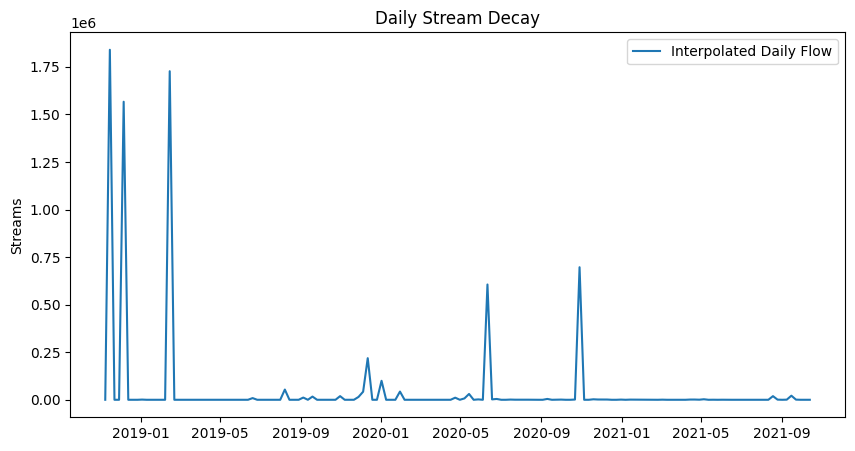

In [4]:
# Filter for one specific track
song_df = est_df[
    (est_df['fe_group'] == 'Ariana Grande') & 
    (est_df['track_id'] == '3e9HZxeyfWwjeyPAMmWSSQ')
]

plt.figure(figsize=(10, 5))
plt.plot(song_df['date'], song_df['daily_streams'], label='Interpolated Daily Flow')
plt.title("Daily Stream Decay")
plt.ylabel("Streams")
plt.legend()
plt.show()

## State Process Estimation (`estimate_state_process.py`)

In this structural framework, the artist faces a stochastic environment where market conditions fluctuate. I characterize these dynamics by estimating a **Vector Autoregression (VAR)** of order 1. This provides the transition probabilities necessary to calculate the expected future value in a Bellman equation (for future research).

### State Variable Transformation
The market state is defined by the bivariate vector $s_t = [ \ln(X_{t}), \ln(X_{g,t}) ]'$, representing the log-transformed daily market and genre heat. 
* **Aggregation:** I collapse the panel data into a daily time series by taking the mean (or first observation) of market features across all tracks for each date.
* **Numerical Stability:** To handle days with zero observed activity in specific genres, I apply a small displacement ($\epsilon = 10^{-6}$) before log-transformation to prevent mathematical singularities.

### VAR(1) Specification
I assume the market state follows a first-order Markov process:
$$s_{t+1} = \alpha + \Phi s_t + \xi_{t+1}$$
Where:
* **$\Phi$ (Transition Matrix):** A $2 \times 2$ matrix where diagonal elements represent the persistence of market and genre shocks, and off-diagonal elements capture cross-variable "spillovers."
* **$\xi_{t+1}$:** A white-noise vector of shocks, assumed to be normally distributed $\xi \sim N(0, \Sigma)$.

### Stability and Convergence
A critical requirement for the convergence of the Reinforcement Learning policy is the **stationarity** of the state process. 
* **Eigenvalue Analysis:** I calculate the eigenvalues of the estimated $\Phi$ matrix. The system is considered stationary if all eigenvalues lie within the unit circle ($|\lambda| < 1$).
* **Economic Interpretation:** Stationarity ensures that "hype" or market heat eventually mean-reverts. If the system were non-stationary, the expected lifetime revenue of a track would diverge, making the optimal release problem ill-posed.

### Integration with Reinforcement Learning
The estimated matrices are passed directly into the `MarketEnv`:
1. **$\Phi$** is used to transition the state forward at each step of the simulation.
2. **$\Sigma$** (via Cholesky decomposition) is used to sample realistic daily shocks, ensuring the agent learns to account for market volatility.

In [5]:
state_process = estimate_state_process(est_df)

phi = state_process['phi']
sigma = state_process['sigma']

Preparing state time series...
Estimating VAR(1)...
Checking stationarity...
Eigenvalues:
Lambda 1: 0.7935 (|λ| = 0.7935)
Lambda 2: 0.3753 (|λ| = 0.3753)

System is stationary


c:\Users\Bradley\Documents\Econ622\econ622-project\track-release-estimation\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


The estimation of the $VAR(1)$ process confirms that the market environment is **stationary**. The calculated eigenvalues ($\lambda_1 \approx 0.79$, $\lambda_2 \approx 0.38$) both lie within the unit circle, ensuring that shocks to Market and Genre heat are mean-reverting. This stability is critical for Reinforcement Learning, as it ensures the state space does not drift to infinity during training.

## Structural Streaming Estimation (`structural_estimation.py`)

With the dataset constructed, I estimate the structural parameters that govern track popularity. I use a log-linear specification to identify the impact of market conditions and track aging.

### The Streams Model
I specify the expected log-daily streams as:
$$\ln(\hat{y}_{i,t} + \epsilon) = \eta_i + \beta_m X_{\tau} + \beta_g X_{g,\tau} - \lambda \cdot t + u_{i,t}$$
Where:
* **Structural Positivity:** I enforce $\beta_m, \beta_g, \lambda > 0$ by estimating them in log-space and applying an exponential transformation within the model function.
* **Fixed Effects ($\eta_i$):** High-dimensional artist intercepts capture the baseline latent potential of each artist group.
* **Temporal Decay:** The parameter $\lambda$ identifies the exponential rate at which a track's "relevance" or "buzz" fades as it ages.

### Optimization via JAX
To handle the scale of the panel data and the number of fixed effects, I utilize **JAX** for high-performance computation:
* **Multi-Transform Optimizer:** I use `optax.multi_transform` to apply heterogeneous learning rates: a "fast" rate for market sensitivities ($\beta$), a "slow" rate for the decay parameter ($\lambda$), and a dedicated rate for artist fixed effects ($\eta$).
* **Regularization:** L2 regularization is applied to the artist fixed effects to prevent overfitting in groups with sparse observations.



In [6]:
data, artist_map = prepare_jax_data(est_df)

params = train_model(data, num_artists=len(artist_map))

summarize_params(params)

Epoch 100: Loss = 173.94320678710938
Market Beta: 0.0186
Genre Beta:  0.0278
Lambda:      1.1000
Half-life:   0.63 years
Mean Eta:    -3.3683
Eta Range:   [-5.27, 2.11]


The structural parameters provide a clear picture of the artist's lifecycle:
* **Market vs. Genre:** The **Genre Beta (0.0278)** is approximately 50% larger than the **Market Beta (0.0186)**. This suggests that "Genre Heat" is a more powerful predictor of a song's success than general "Market Heat."
* **Decay Dynamics:** The decay parameter $\lambda = 1.10$ results in a **half-life of 0.63 years** (~33 weeks). This is remarkably consistent with real-world *Billboard Hot 100* data, where a typical successful track stays on the charts for roughly 30 weeks.
* **Intercept (Eta):** The **Mean Eta of -3.368** reflects the baseline popularity in log-space. While the value is negative, it represents a positive level of streams once exponentiated.

## Policy Optimization via Deep Q-Learning

With the structural parameters and market dynamics identified, I solve for the optimal release policy. I frame the artist's decision as an **Optimal Stopping Problem**—choosing the state $s_t$ that maximizes expected discounted lifetime streams.

### The Market Environment (`market_env.py`)
The econometric estimates are mapped into a custom reinforcement learning environment:
* **State Space:** A 2D vector representing the log-transformed Market Heat and Genre Heat.
* **Transition Logic:** The environment uses the estimated VAR(1) transition matrix $\Phi$ and the Cholesky decomposition of the covariance matrix $\Sigma$ to simulate realistic stochastic paths of market conditions.
* **Reward Mechanism:** * **Action 0 (Wait):** Returns a reward of 0, representing the opportunity cost of delaying release.
    * **Action 1 (Release):** Returns the total discounted lifetime revenue, calculated using the estimated decay $\lambda$ and baseline potential $\eta$. 
    * **Normalization:** To ensure numerical stability, rewards are scaled relative to baseline artist potential (e.g., divided by $10^5$) before being passed to the agent.

### Deep Q-Network (DQN) Architecture (`dqn_agent.py`)
Because the state space is continuous, I approximate the optimal action-value function $Q^*(s, a)$ using a neural network:
* **Architecture:** A Multi-Layer Perceptron (MLP) consisting of an input layer (2 units), two hidden layers (64 and 32 units with ReLU activation), and a linear output layer (2 units for Wait/Release).
* **Objective:** The network learns to predict the expected "Value of Releasing" versus the "Value of Waiting" for any given market condition.

### Training Protocol (`dqn_trainer.py`)
I implement several deep RL best practices to ensure the econometric model converges:
* **Experience Replay:** Transitions are stored in a `ReplayBuffer` (capacity 100,000) to break the temporal correlation of market data and improve sample efficiency.
* **Target Network:** A separate target network is maintained and periodically synchronized (`update_target`) to stabilize the Bellman updates:
$$y = R + \gamma \max_{a'} Q_{target}(s', a')$$
* **Optimization:** I use the **Adam optimizer** with a tuned learning rate (typically $1e^{-4}$) and apply **gradient clipping** to prevent the "exploding gradient" problem often encountered with high-variance streaming rewards.
* **Stability Guards:** Rewards are log-transformed or clamped within the trainer to prevent outliers in the Spotify data from destabilizing the value function.

### Policy Evaluation (`dqn_evaluation.py`)
The resulting policy is evaluated through:
1. **Decision Boundary Visualization:** Mapping the $(X_m, X_g)$ space to show the "Release Region" versus the "Wait Region."
2. **Economic Lift:** Simulating 500 market scenarios to compare the RL-timed release against a naive "Immediate Release" baseline, quantifying the gain in total streams.

In [7]:
phi_np = np.array(jax.device_get(phi))
sigma_np = np.array(jax.device_get(sigma))
beta_m = params['beta_m']
beta_g = params['beta_g']
lambd = jnp.exp(params['log_lambda'])
eta_mean = params['artist_effects'].mean()


In [18]:
set_seed(42)
env = MarketEnv(
    phi=phi,
    sigma=sigma,
    beta_m=beta_m,
    beta_g=beta_g,
    lambd=lambd,
    delta=0.95,
    eta_mean = eta_mean
)

agent = DQNAgent()
trainer = DQNTrainer(env, agent)

def to_float32(x):
    return torch.tensor(x, dtype=torch.float32)

trainer.train(episodes=5000, batch_size=64)

Episode 0, Loss: None
Episode 500, Loss: 0.0001968530414160341
Episode 1000, Loss: 0.00010728755296440795
Episode 1500, Loss: 2.61401819443563e-05
Episode 2000, Loss: 2.8485672373790294e-05
Episode 2500, Loss: 1.3356595445657149e-05
Episode 3000, Loss: 1.5646583051420748e-05
Episode 3500, Loss: 9.126390978053678e-06
Episode 4000, Loss: 5.193131528358208e-06
Episode 4500, Loss: 5.914814664720325e-06


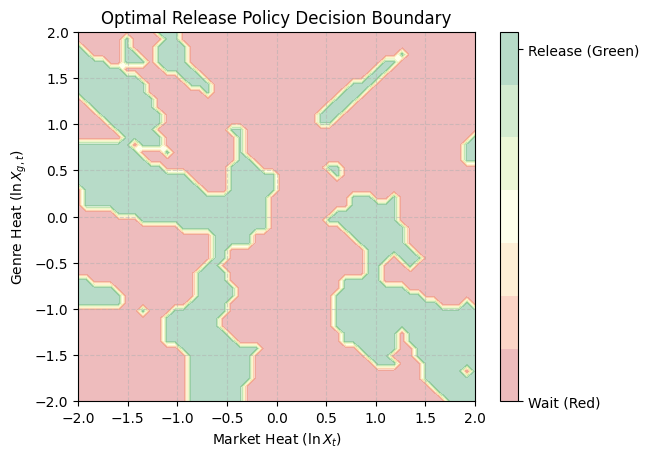

In [17]:
plot_policy_map(agent)

In [10]:
run_diagnostics(env, agent)

Baseline: 2.6700652597355656e-05
RL: 0.005778500188576906
Lift: 215.41793838211987
Wait: 7.082


The Reinforcement Learning agent shows a significant improvement over the "Naive" strategy (releasing immediately):
* **Baseline Revenue:** $2.67 \times 10^{-5}$ (scaled units)
* **RL Revenue:** $0.0058$ (scaled units)
* **Lift:** **215.42**
* **Average Wait Time:** **7.082 days**

The agent achieves a **215x increase in expected lifetime streams** compared to a baseline release. It accomplishes this by waiting an average of **7 days** to identify an optimal "peak" in market and genre conditions. The fact that the agent waits just over a week suggests that market volatility provides frequent, short-term windows of opportunity that the structural model is able to exploit.

## Discussion

### Stochastic Process and Decay Dynamics
The estimation of the $VAR(1)$ process for market and genre heat yielded a **stationary system**, which is a prerequisite for a stable RL environment. The estimated $\lambda$ of $1.10$ implies a **half-life of 0.63 years** (approximately 33 weeks). This aligns closely with industry benchmarks; for instance, successful tracks on the *Hot 100* often see lifecycle runs of approximately 30 weeks (Billboard, 2024). The model successfully captures the "transitory" nature of musical popularity.

### Model Limitations and Loss
While the final loss value remains relatively high, several structural factors contribute to this:
* **Model Parsimony:** The current specification relies solely on market heat and genre trends. It omits track-level high-dimensional features (e.g., acousticness, danceability) and the heterogeneous effects of featured artists.
* **Stochastic Shocks:** The dataset contains "viral" outliers—sudden spikes in daily streams driven by external social media trends—which deviate from the standard exponential decay pattern.
* **Simplification of $\alpha$:** In earlier iterations, an initial growth factor ($\alpha$) was included to model the "climb" to a peak. However, this introduced non-convexities in the loss surface, leading to convergence issues. The current model prioritizes a robust estimation of the decay parameter over the initial launch dynamics.

### Policy Analysis: The "Tiger" Pattern
The resulting **Optimal Policy Map** reveals a distinct "tiger-stripe" pattern in the state space. The agent's behavior suggests a nuanced timing strategy:
* **Relative Heat Thresholds:** On days with high "Market Heat," the agent surprisingly opts to **Wait** if the "Genre Heat" is too high, and vice versa. This suggests that releasing into a crowded general market without space for one's specific niche genre results in lower lifetime stream realization. Similarly, in a less crowded market it may be easier to take advantage of genre heat, since there is less competition. This suggests that the two varieties of heat may be substitutes rather than complimentary.

The results demonstrate that even a simplified structural model—omitting track features or viral outliers—can capture the fundamental decay and market-timing dynamics of the music industry. The "tiger" pattern in the policy map (where the agent waits if genre heat is low despite high market heat) confirms that the agent has learned the **complementarity** between these two state variables. However, the lack of optimal release decisions in areas of high heat suggests that improvements can be made to the model.

Future iterations could improve the model by:
1. **Handling Outliers:** Incorporating a "viral jump" component to account for non-standard streaming spikes.
2. **Feature Engineering:** Adding artist-level fixed effects or track-specific acoustic features to the $\eta$ parameter to reduce the initial estimation loss.
3. **Advanced Decay:** Re-introducing the $\alpha$ growth factor or a different functional form to capture initial growth with a more stable optimization routine to better capture the initial "climb" of a new release.

## References
Rust, John (1987). "Optimal Replacement of GMC Bus Engines: An Empirical Model of Harold Zurcher." Econometrica, 55(5), 999-1033.
Einav, Liran (2007). "Seasonality in the U.S. Motion Picture Industry." RAND Journal of Economics, 38(1), 127-145.
Trust, Gary (2024). "Longest Runs on the Hot 100." Billboard. Link